# Week-3 Day-3

---

## Wednesday: SQL Aggregation, Subqueries & CTEs
### Goal

Build on JOINs by learning how to summarize data using aggregate functions, filter grouped results, and write nested/structured queries using subqueries and Common Table Expressions (CTEs). Students should be able to answer complex business questions that require multi-step logic, not just table combination.

### Learning Topics
* GROUP BY & Aggregate Functions (COUNT, SUM, AVG, MIN, MAX).
  * This was coveredd in detail in the previous day's task.
  * Groupby is used to make buckets and aggregate things and return a single row
  * Aggregate functions are just simple functions in SQL that you use to perform diff calculations, these functions run after the WHERE clause not before it (even though WHERE clause is written after it mostly)
* HAVING vs WHERE.
  * WHERE filters rows and HAVING filters groups.
  * Keep in mind that a WHERE clause is executed before aggregation (stuff like SUM(amount) etc)
* Subqueries (Scalar, Correlated, Non-Correlated).
  * Answered in detail in the readme.md
* Subqueries in SELECT, WHERE, and FROM clauses.
  * A subquery in WHERE is for filtering and a subquery in FROM is for temp result table and a subquery in SELECT is for added a calculated column
* Common Table Expressions (CTEs) using WITH.
  * Another way of building a subquery basically but you can assign a temporary name to the subquery, this will improve code readability, not much else for the most part
* Window Functions (Introduction): ROW_NUMBER(), RANK(), DENSE_RANK().
  * I answered this thoroughly in the readme.md
* PARTITION BY vs GROUP BY.
  * Both are used for aggregation but groupby will collapse the rows into one whereas parition by will not collapse the rows and return all of them
* CASE WHEN for conditional aggregation.
  * Same as the Switch statement in javascript or any other programming language. You mostly write the Case When in the select clause to print. You have an additional THEN and ELSE and END in the Case When clause as well

---

### Learning Resources

* Kaggle Learn – Advanced SQL (Aggregate Functions & Subqueries) kaggle.com/learn/advanced-sql.
* SQLBolt Lessons 14–18 (Subqueries & Aggregates) sqlbolt.com.
* Mode Analytics SQL Subquery Tutorial mode.com/sql-tutorial/sql-sub-queries.
* PostgreSQL Aggregate Functions Documentation postgresql.org/docs/current/functions-aggregate.html.
* PostgreSQL Window Functions Documentation postgresql.org/docs/current/tutorial-window.html.

---

### Dataset
Continue using the DVD Rental Database from Tuesday (already imported). neon.com/postgresql/getting-started/sample-database

---


### Concept Check
1. What is the difference between WHERE and HAVING?
   - WHERE is used to filter the rows before any groupby operation, also, WHERE runs before any aggregate calculation as well
   - HAVING is used to filter groups/buckets that are built using GROUP BY, you can write aggregate functions inside the filter condition ins HAVING clause because it runs after the aggregate functions execute 
2. When would you use a correlated subquery instead of a JOIN?
   - Joins are used when you need columns from both tables, subqueries are used to return an intermediate result and then use that result in another query. 
     - Correlated queries execute once dynamically for each row evaluated by the outer query, it is dependent on the outer query, it cannot run indepdentantly. Consider an employee and salary and department table. You have to compare the average salary of a department with the salaries of each employee and build a new column that shows percentage of how low/high the employee's salary is from the department's average, that would need a correlated subquery. you would find the avg salary of the department the employee is in, then compare that average with that employee's salary, and then print the high/low percentage result, then if an employee row comes in the outer query that belongs to a different department, the inner query must run again for that department to calculate the average salary in that department, and so on. This problem will be solved with a correlated subquery.
3. What is a CTE, and why is it more readable than a nested subquery?
   - CTEs are simply named subqueries, subqueries are written inline, if you have to write several of them then your SQL looks like a mess reducing code readability and code quality, to prevent this, we can use the WITH keyword to make a CTE and assign it a name and then use that name in our main outer query, this would enhance code readability. But there are several exceptional cases as well
     - Correlated Subqueries: A correlated subquery runs dynamically and will execute multiple times depending on the outer query, the same problems can be solved with JOINS+CTEs which significantly optimizes overall performance of the query. 
     - A CTE runs only once (or a few times, but way less than a correlated subquery), a scalar and non-correlated subquery also run only once, a correlated subquery will run multiple times
     - One Exception, if you are using the EXISTS keyword. a subquery in the WHERE clause can use short circuit evaluation whereas if you write a CTE for this, it won't execute dynamically and hence cannot take advantage of short circuit evaluation  
4. Explain the difference between RANK() and DENSE_RANK().
   - These are already covered in the readme.md file 
5. What does PARTITION BY do differently from GROUP BY?
   - Both of them are used to perform aggregate calculations (PARTITION BY is also used with other window functions like LAG and RANK etc) to group rows into buckets but group by will fully collapse the result into one single row whereas PARTITION BY will not collapse the result and display all the rows and an additional column with the result of the aggregate calculation.
6. Can a subquery return multiple rows? What operator would you use in that case?
   - Yes, subqueries can return multiple rows, but if after the return, you use a normal comparison operator (i.e =, >, <, != etc) then SQL will crash and say "subquery returned more than one row"
   - You must use multi-row operators here, such as IN, ANY, SOME, ALL, EXISTS, NOT EXISTS 
7. Give an example of when CASE WHEN is useful inside an aggregate function.
   - This pattern is called conditional aggregation. Here is an example
     - Pivot rows into columns. Consider you have a table with a column called revenue and another column called quarter. and you have to find total revenue from q1 to q4. You can use a SUM aggregation and put a CASE WHEN inside that, the condition will be quarter = 'q1' for the first aggregation, and you will have the total revenue for the first quarter, just change the condition to q2, q3, and q4 and you will get 4 new columns, each telling the total of the respective quarter. 


---


### Implementation Task
Using only SQL, solve the following business questions.

#### Part 1 — Aggregation Basics
1. Find the total revenue generated per store.

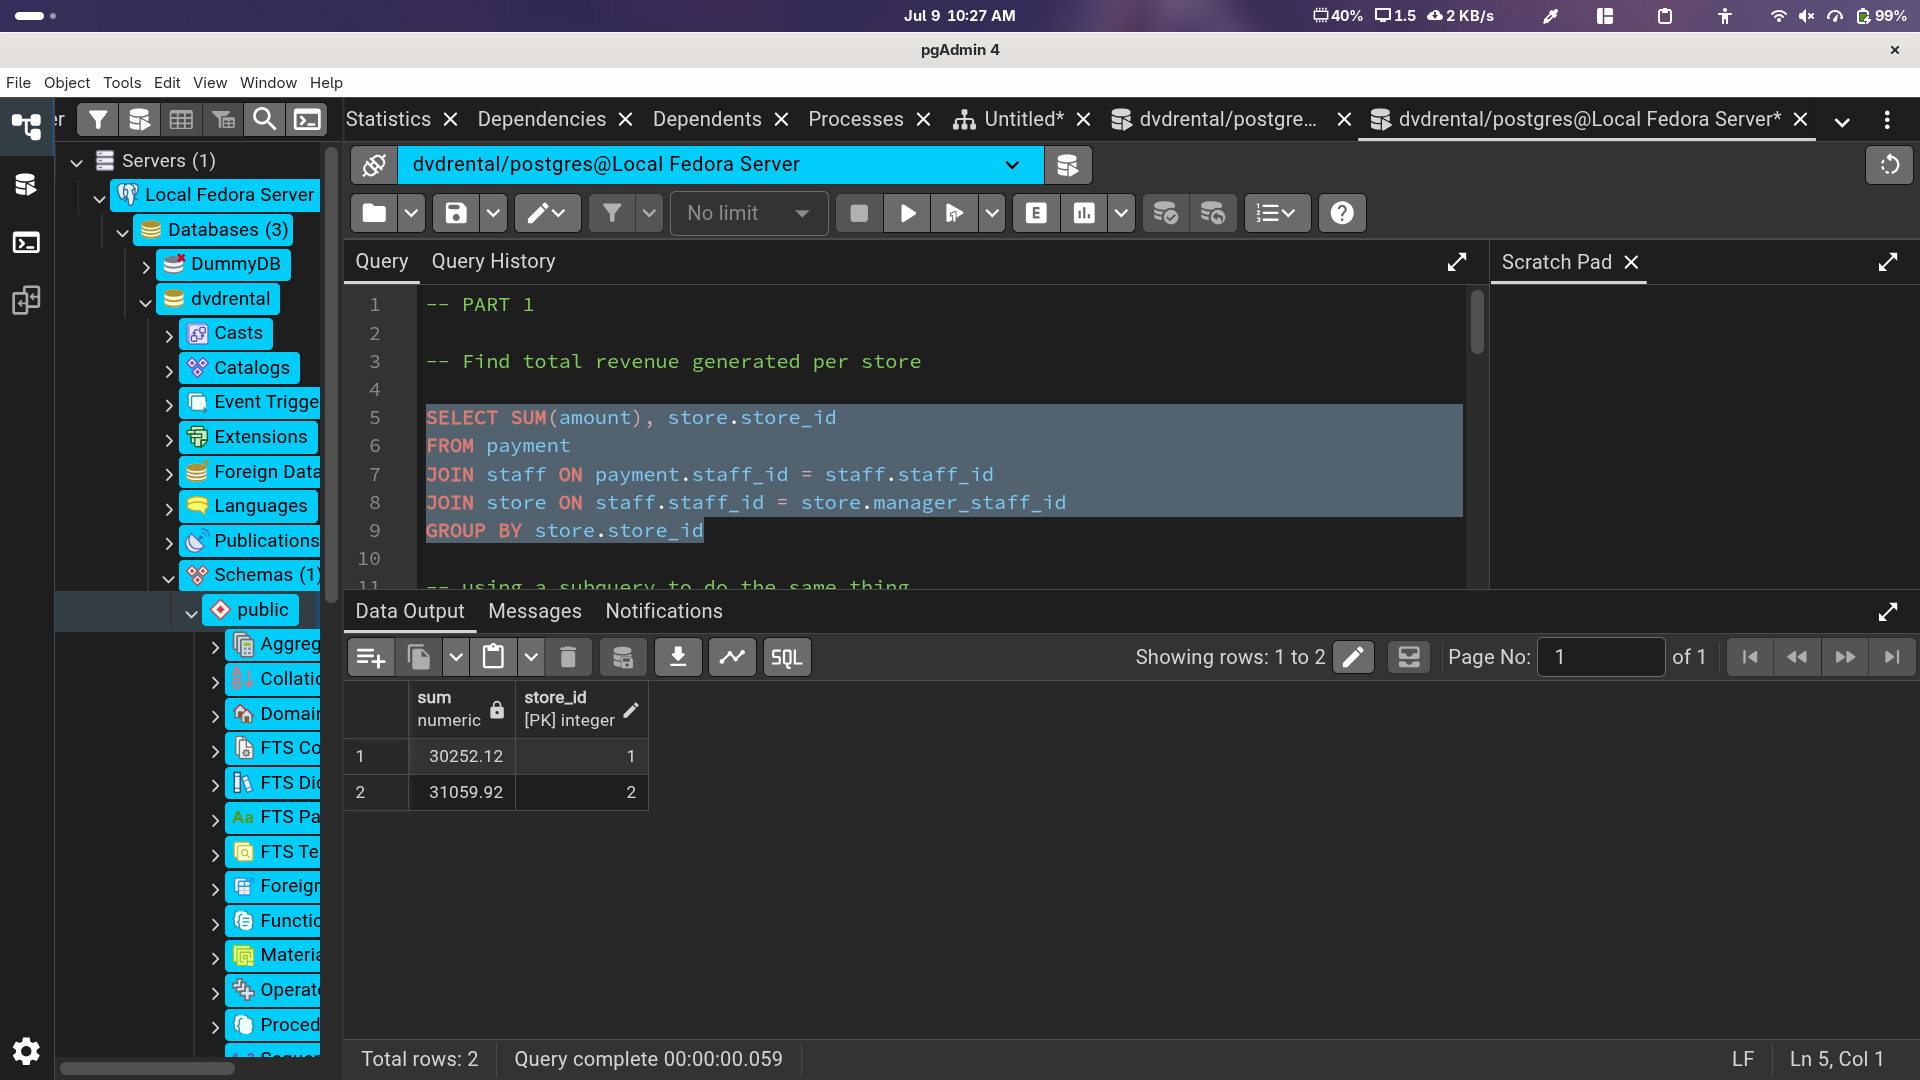

2. Find the average rental duration per film category.

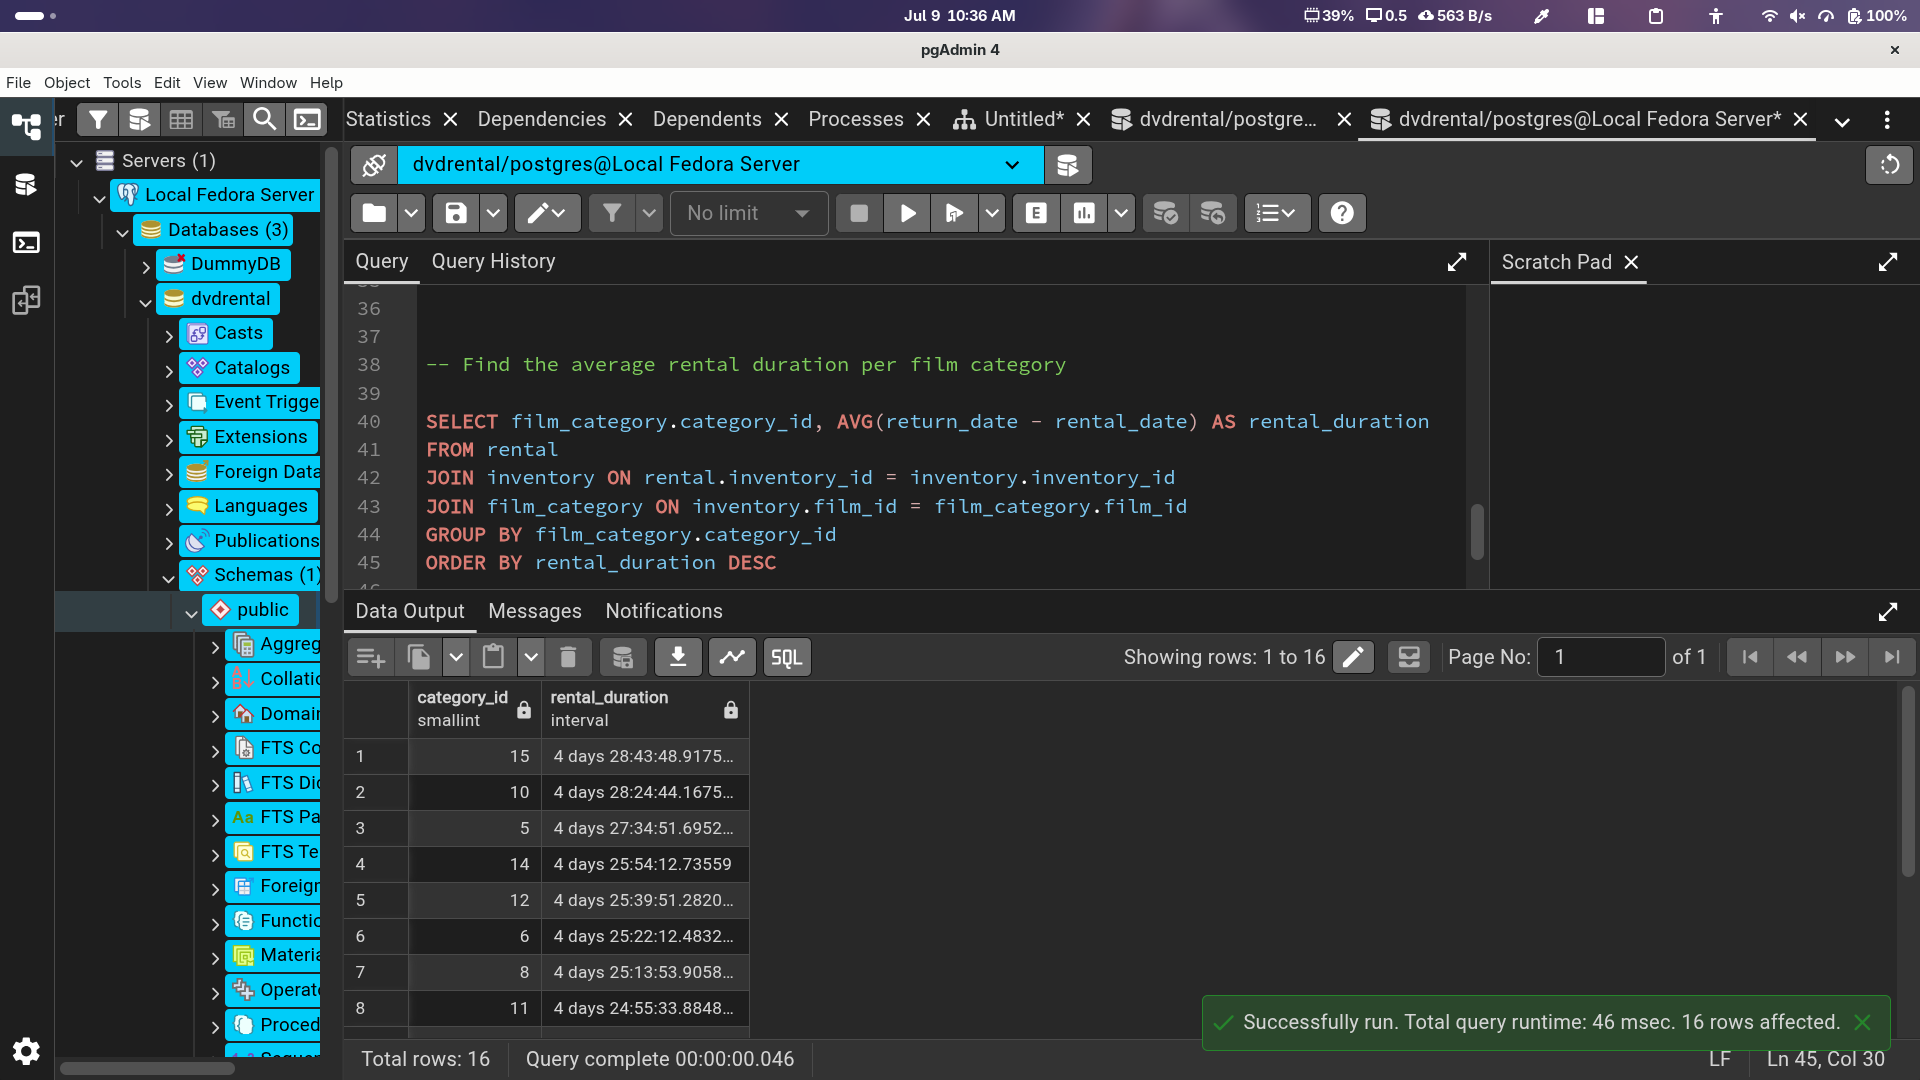

3. Find the number of rentals made each month.

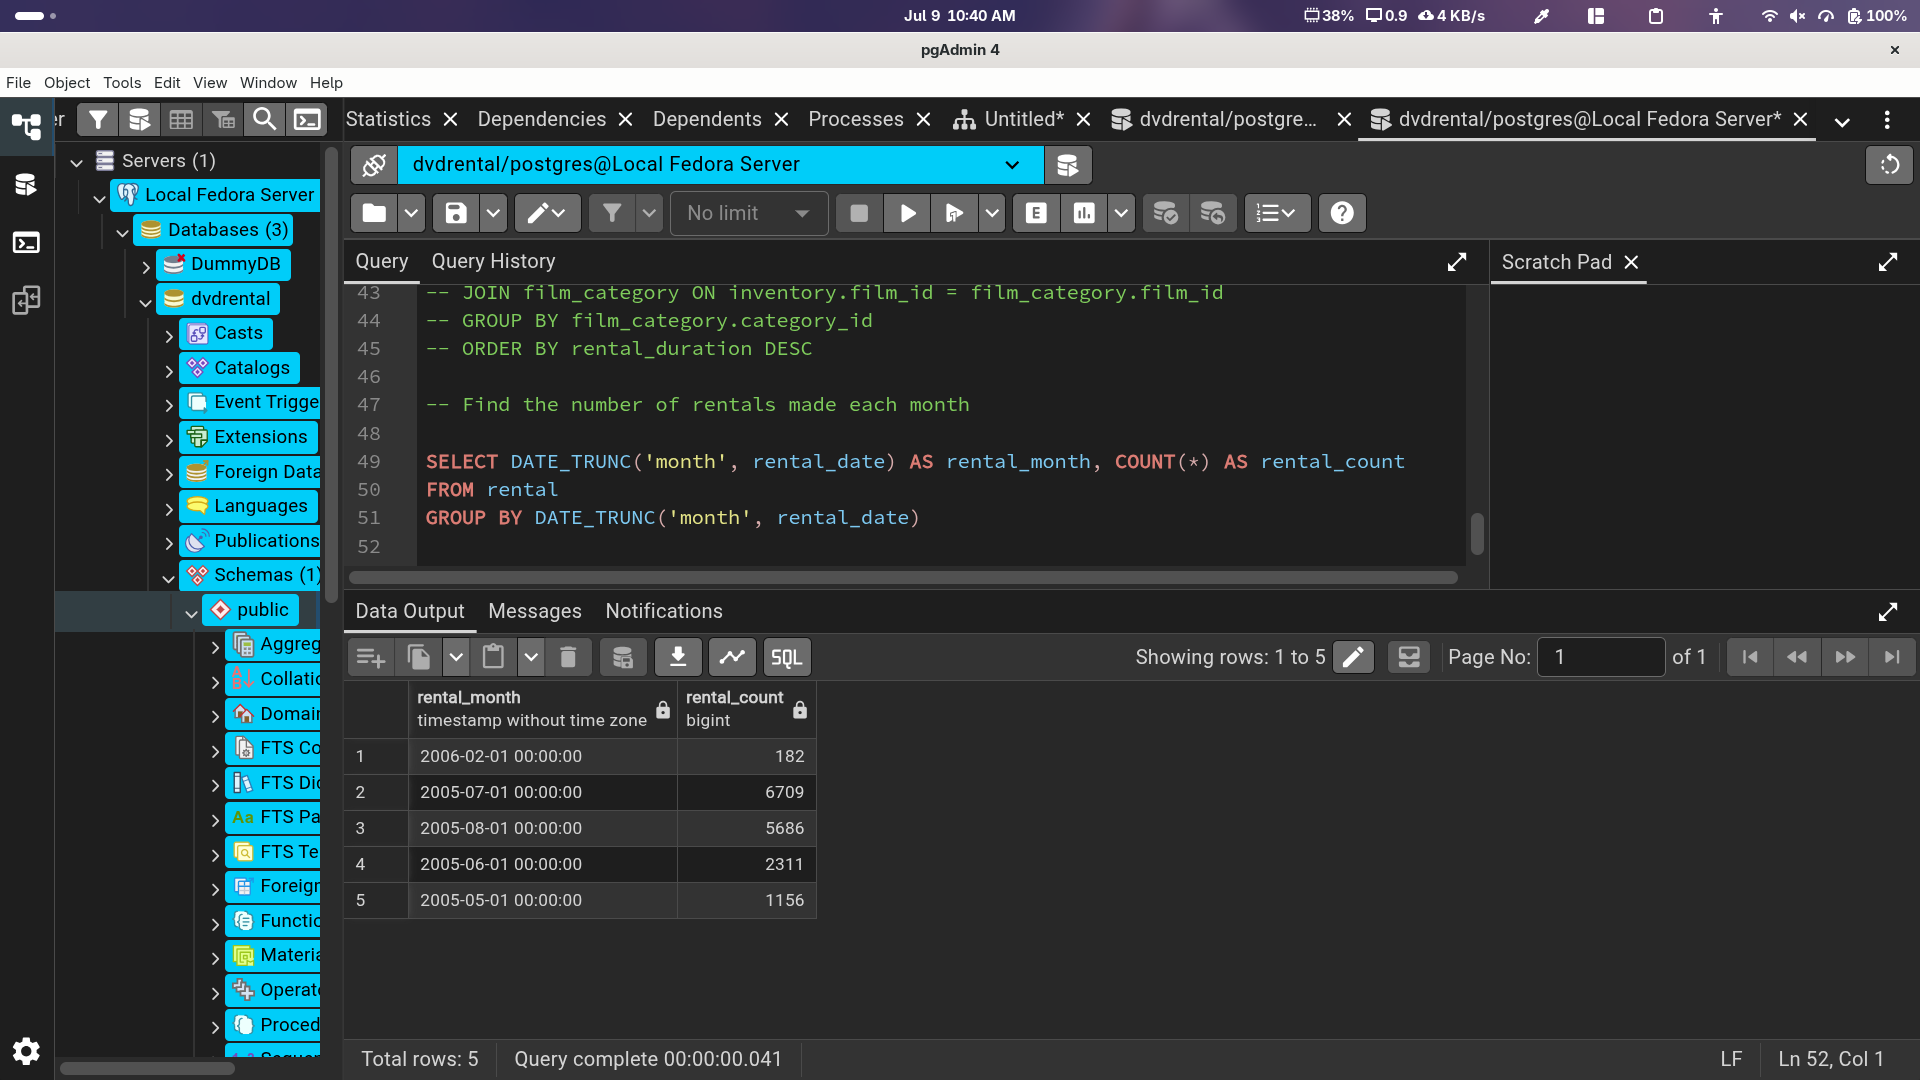

4. Find categories with more than 50 films (use HAVING).

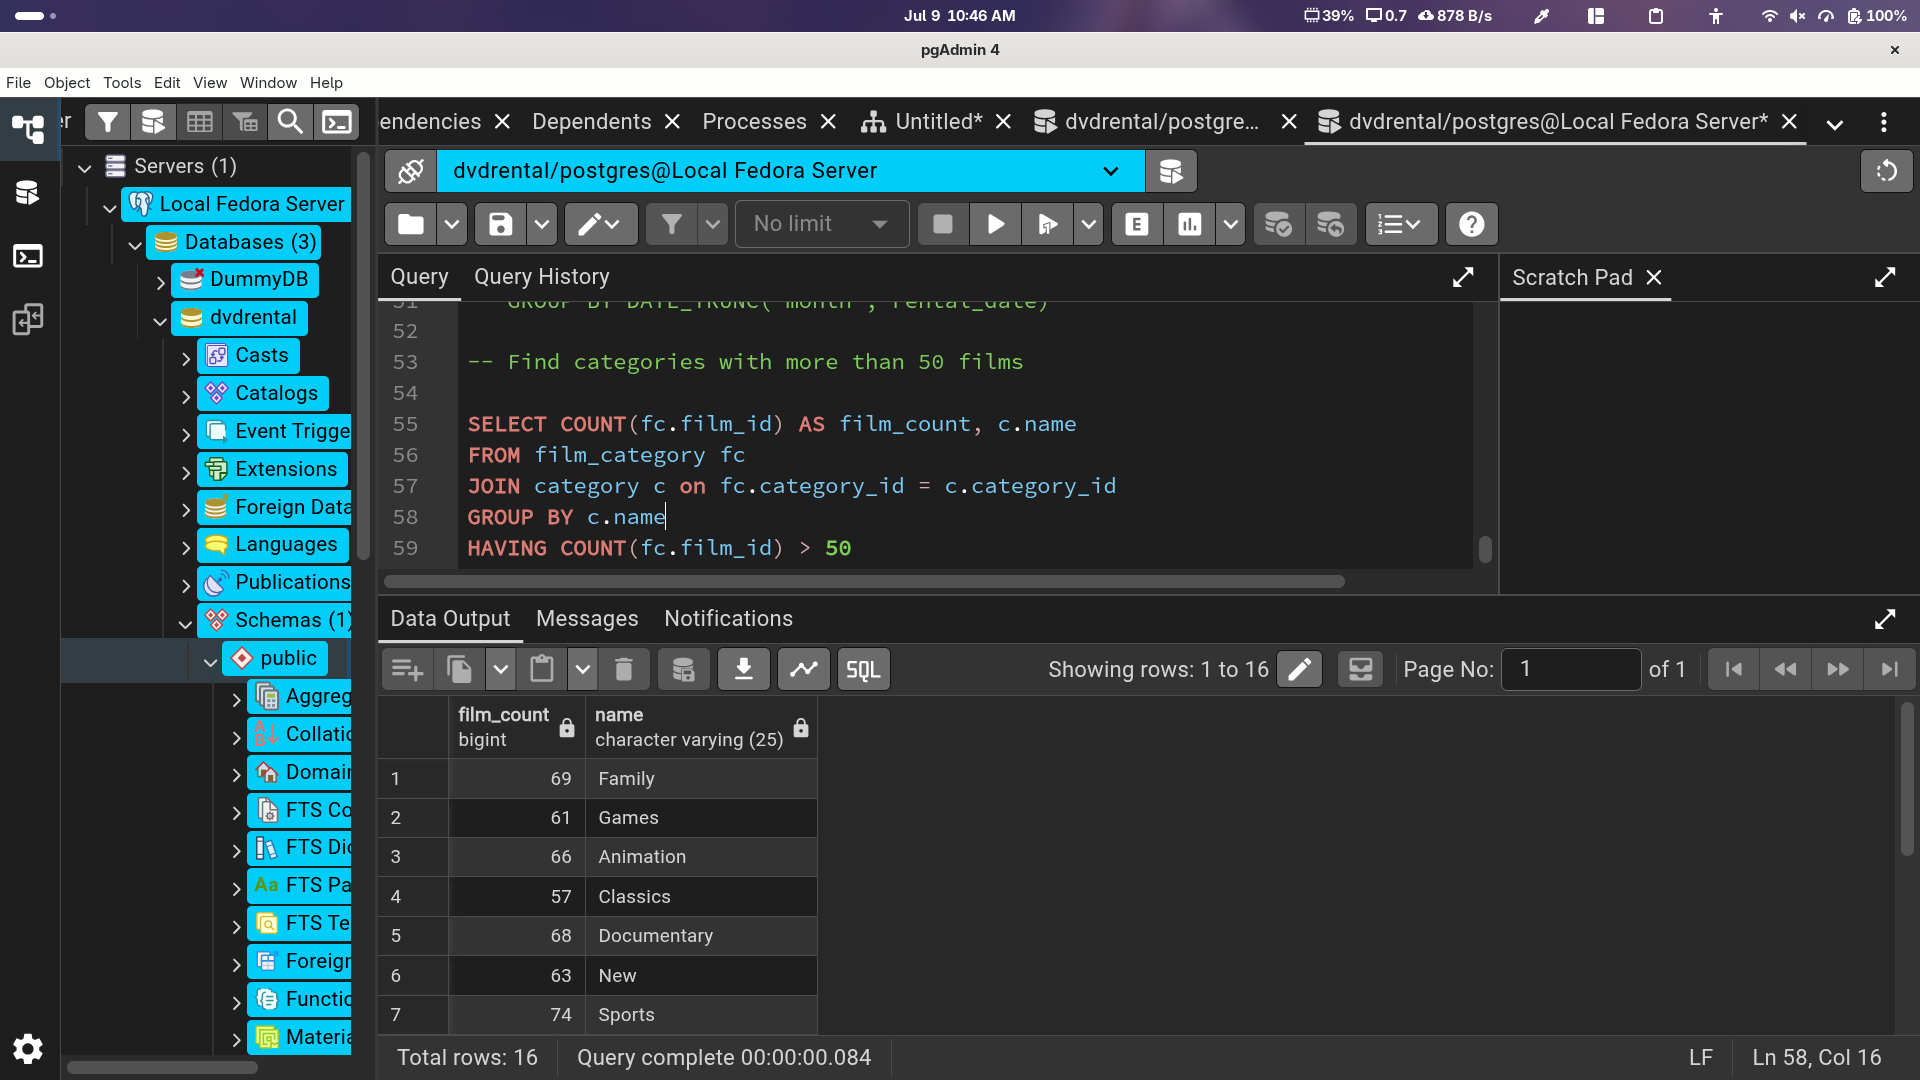


---

#### Part 2 — Subquery Challenges
1. Find customers who spent more than the average customer spend.

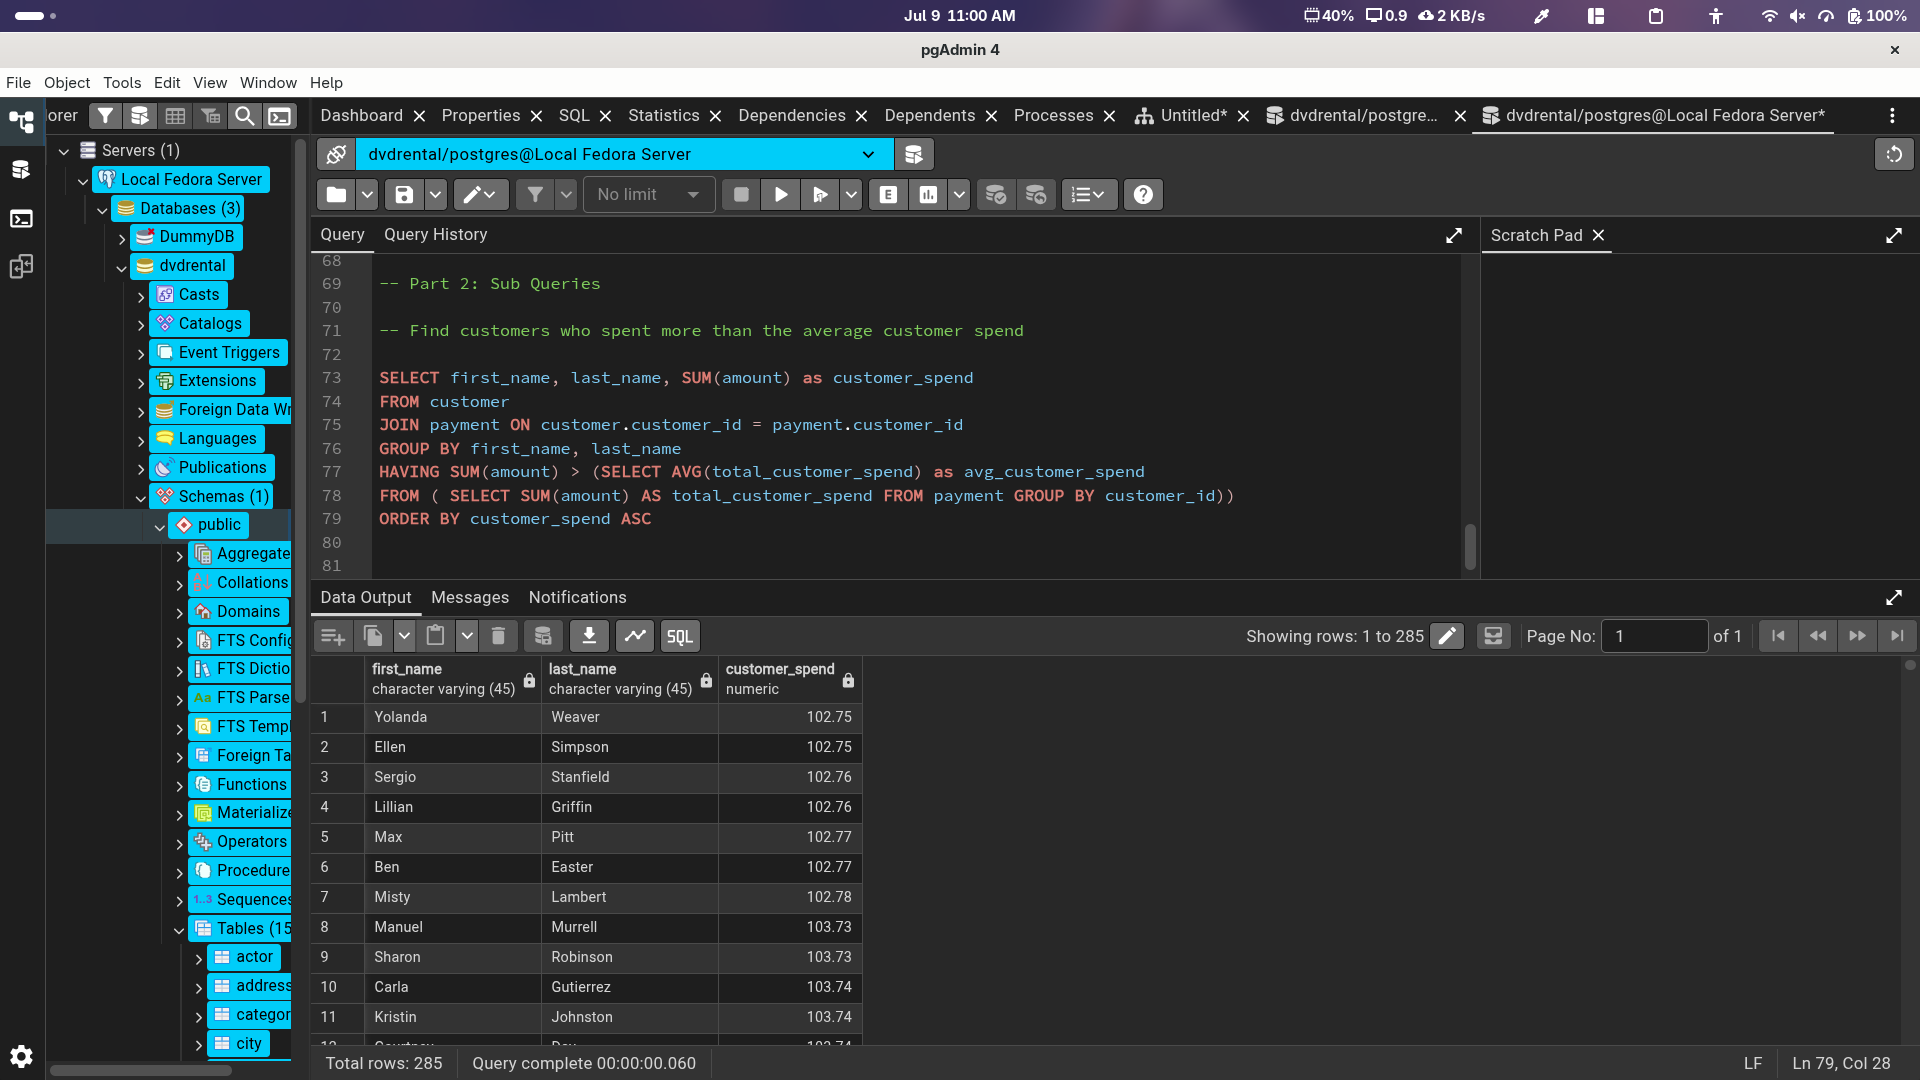

2. Find the film(s) with the highest rental rate in each category (use a correlated subquery).

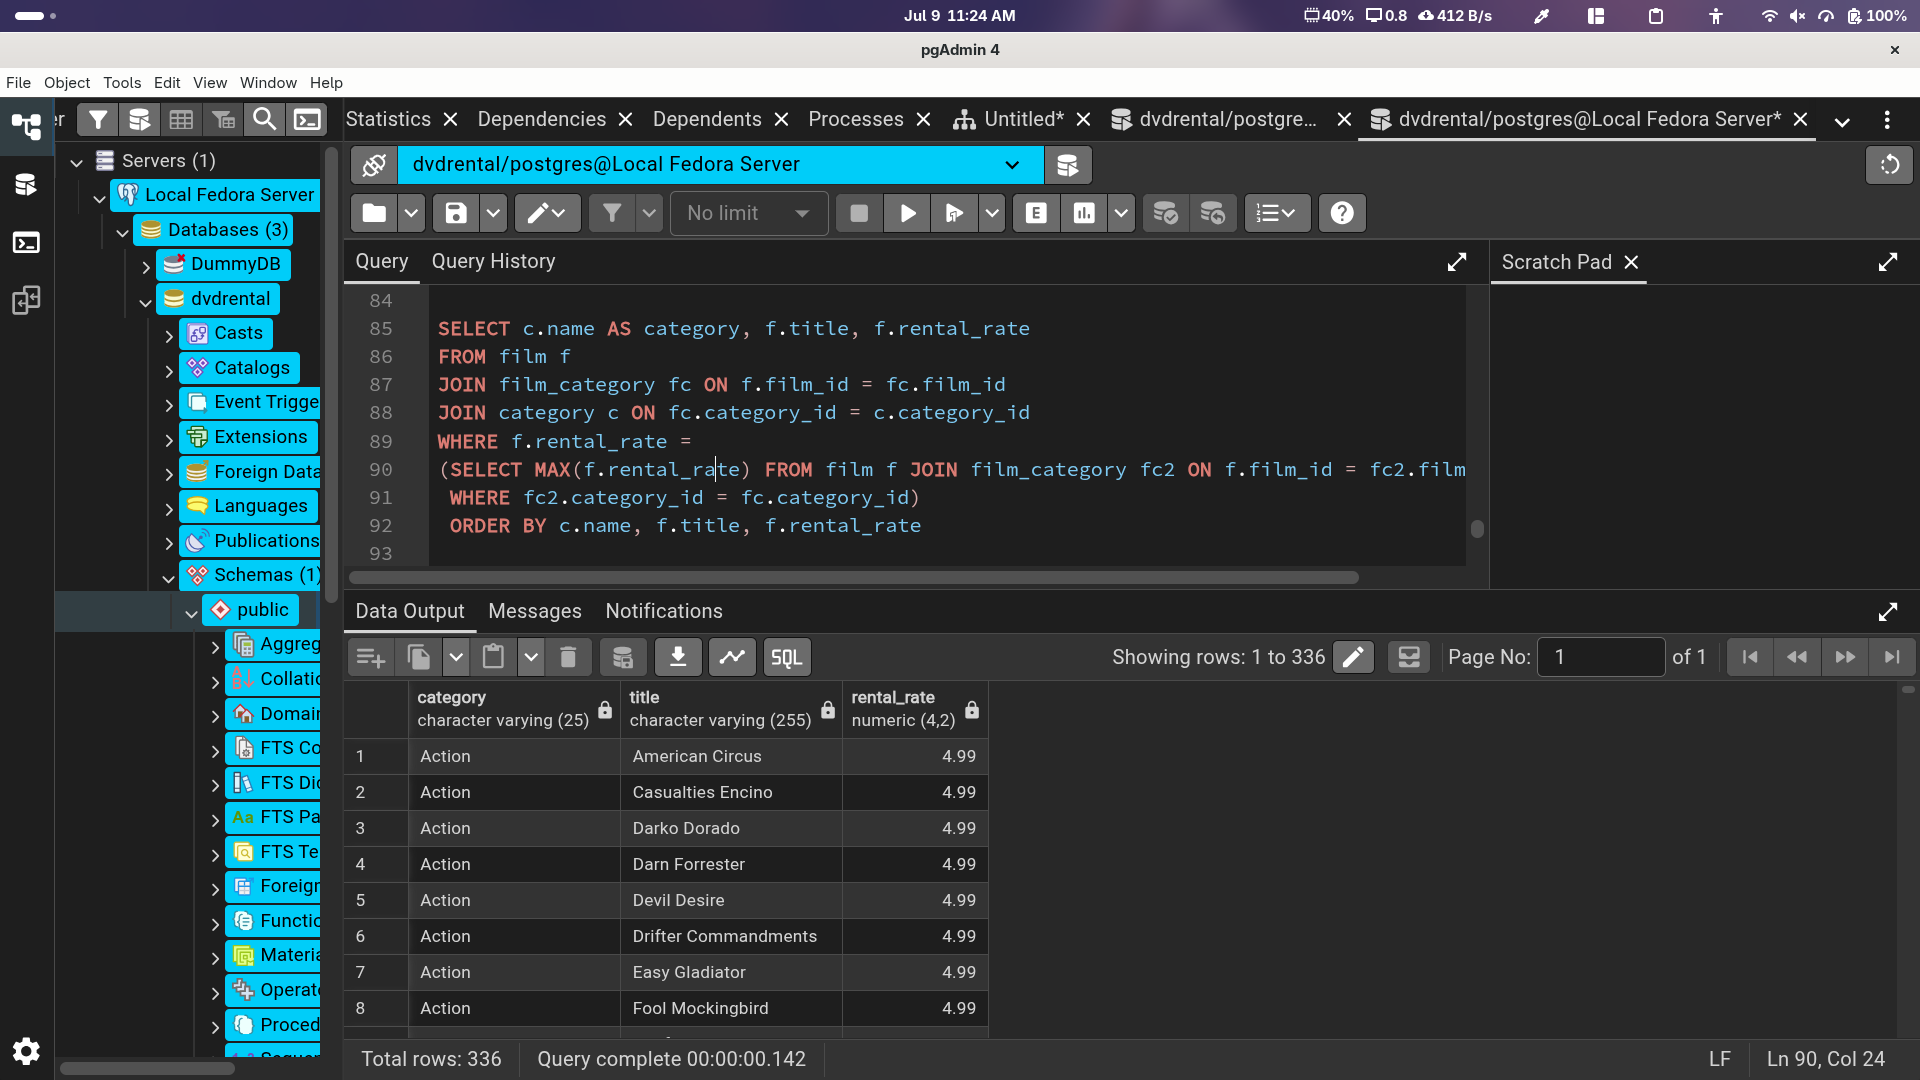

3. Find customers who have never rented a film (use NOT IN / NOT EXISTS).

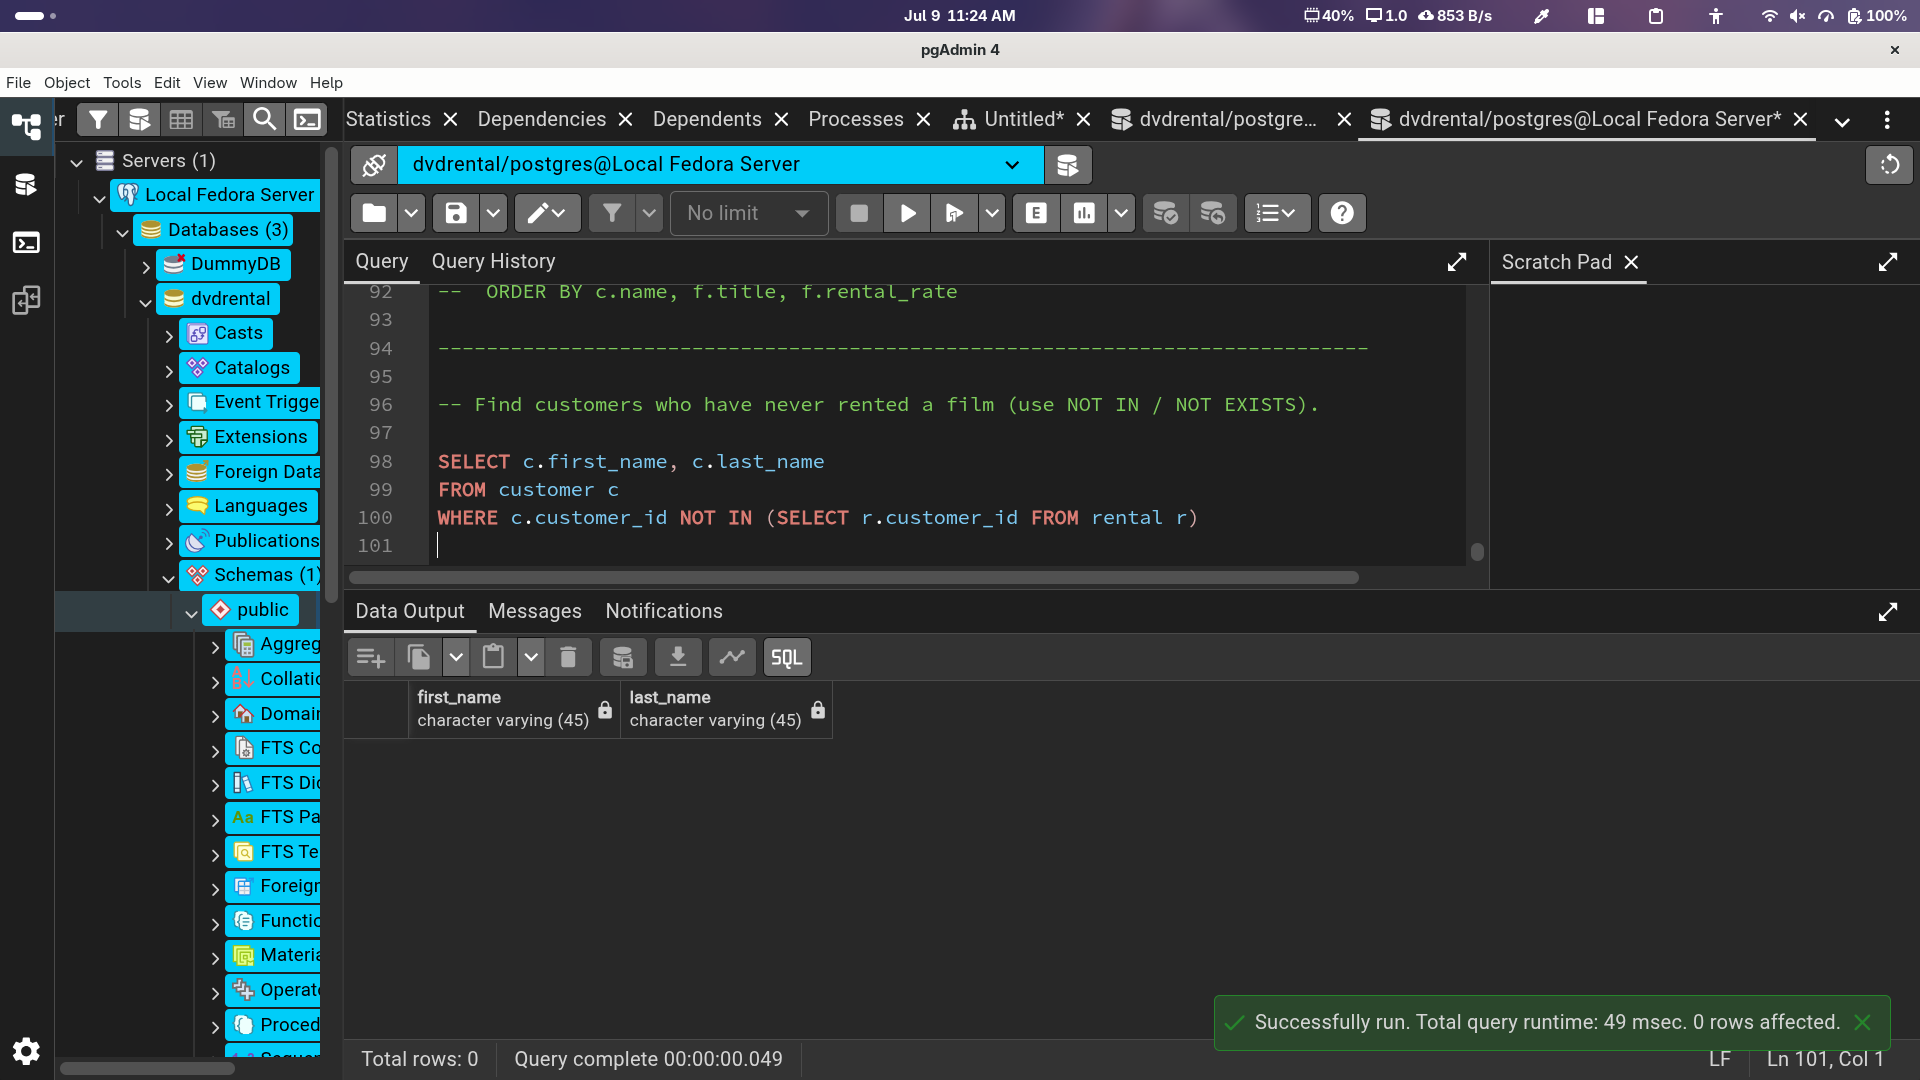

4. Find the store with the highest total revenue using a subquery in the WHERE clause.

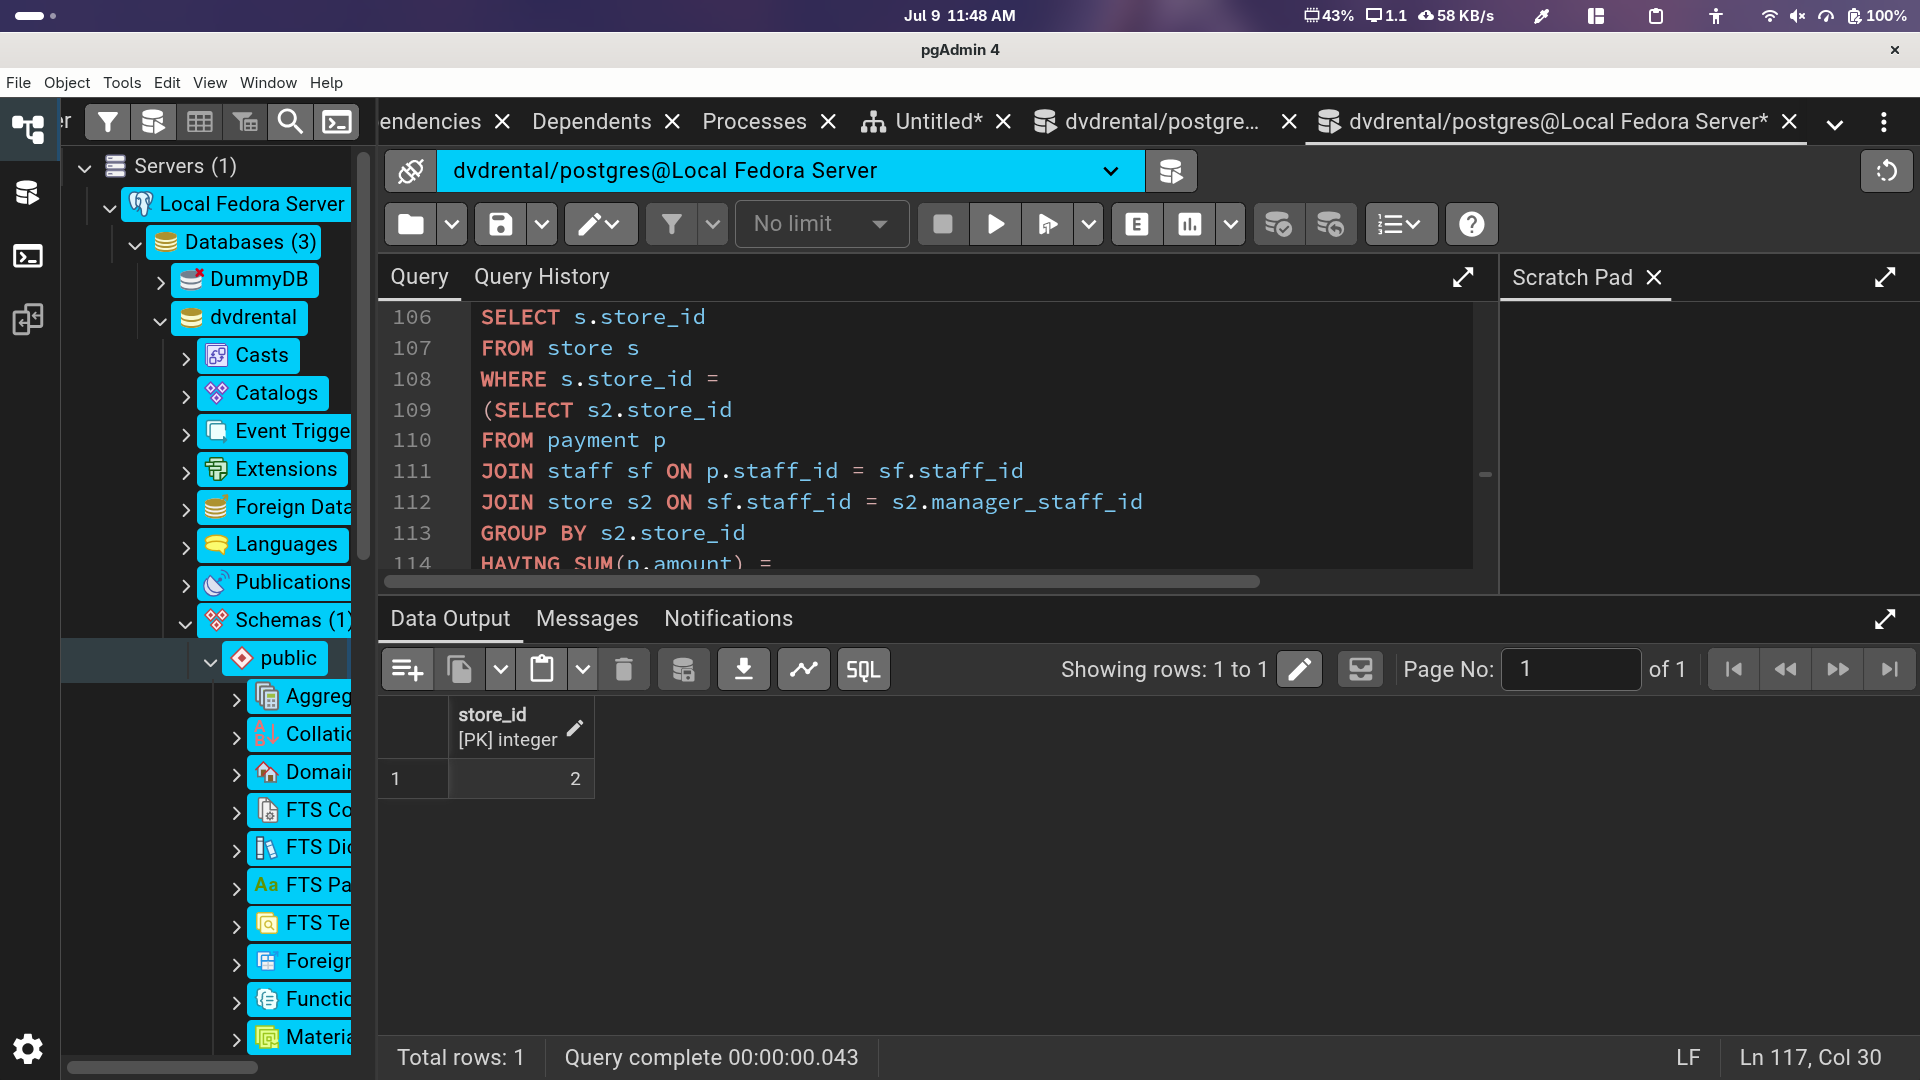

---

#### Part 3 — CTE & Window Function Challenges
1. Using a CTE, rank customers by total spend within each city.

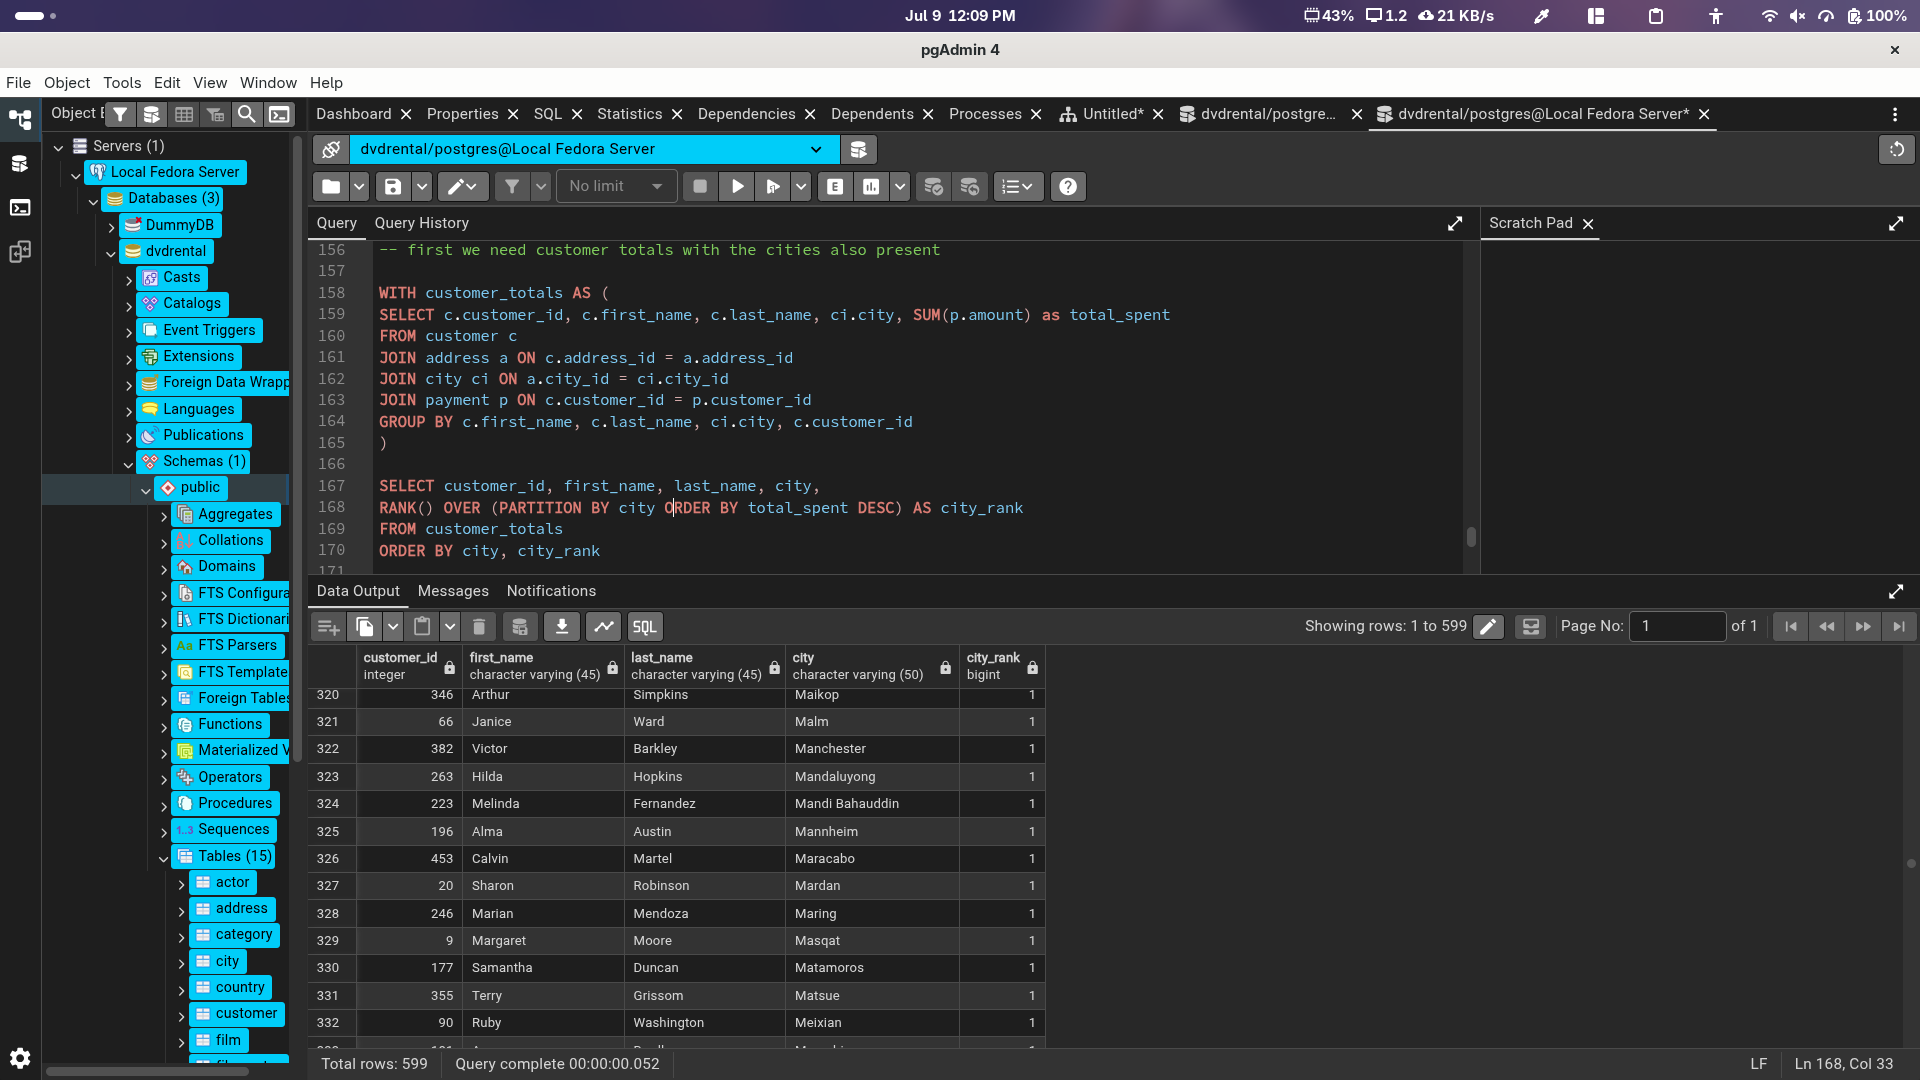

2.  Using ROW_NUMBER(), find the most recently rented film for each customer.

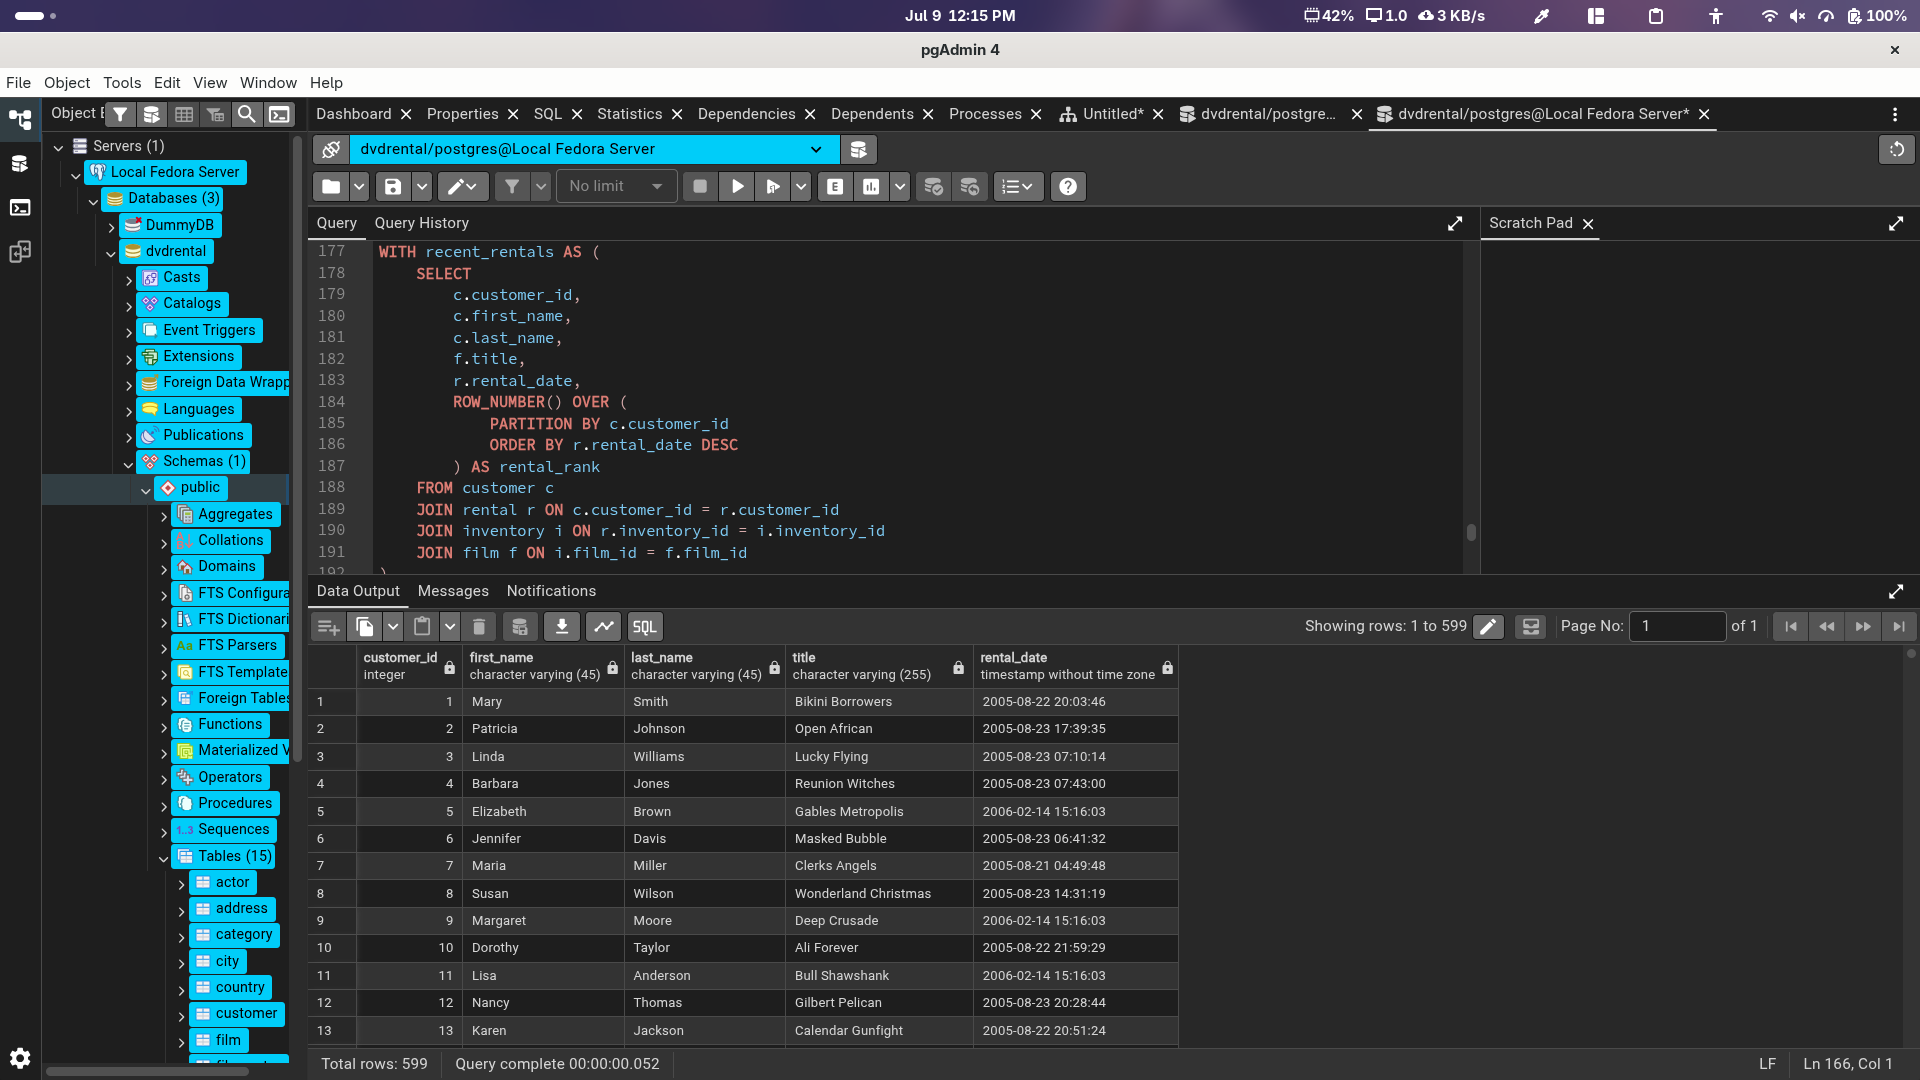

3.  Using a CTE, calculate month-over-month rental revenue growth.

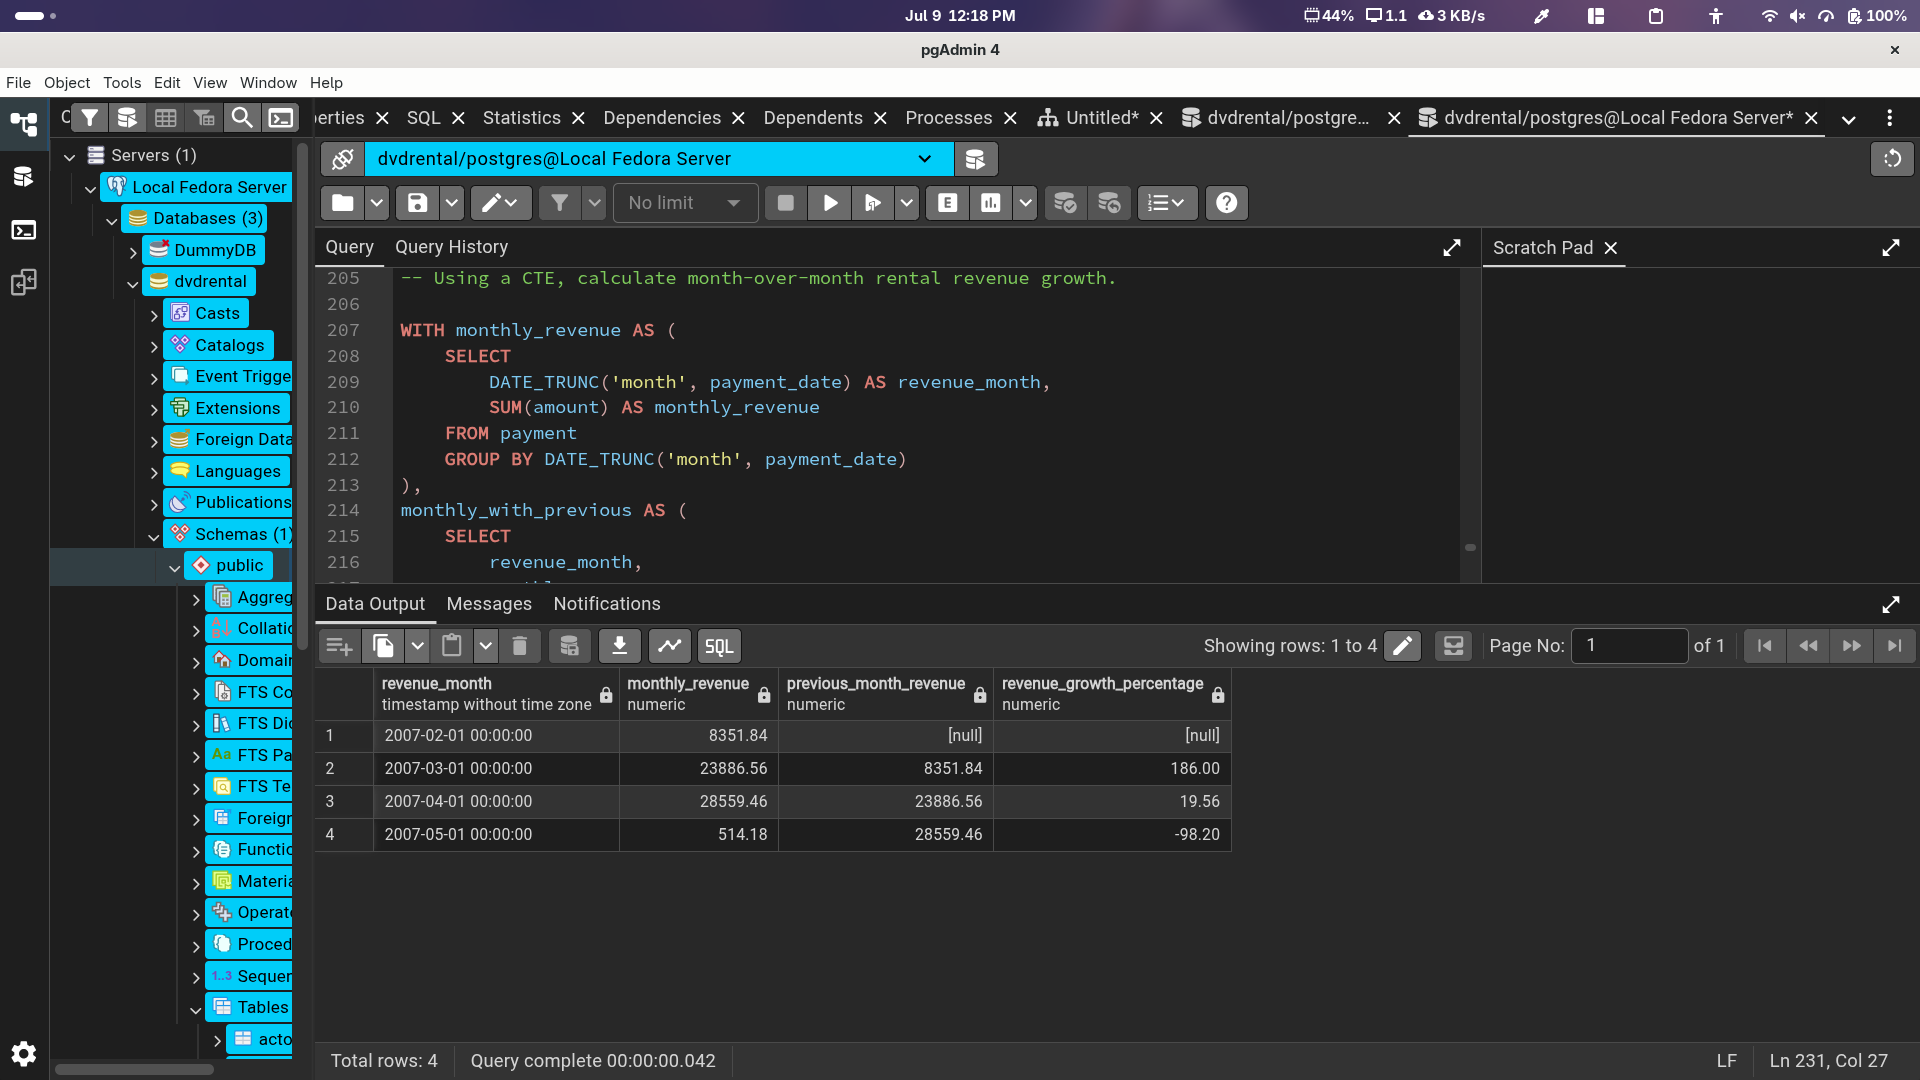

4.  Find the top 3 highest-grossing films per category using RANK() inside a CTE.

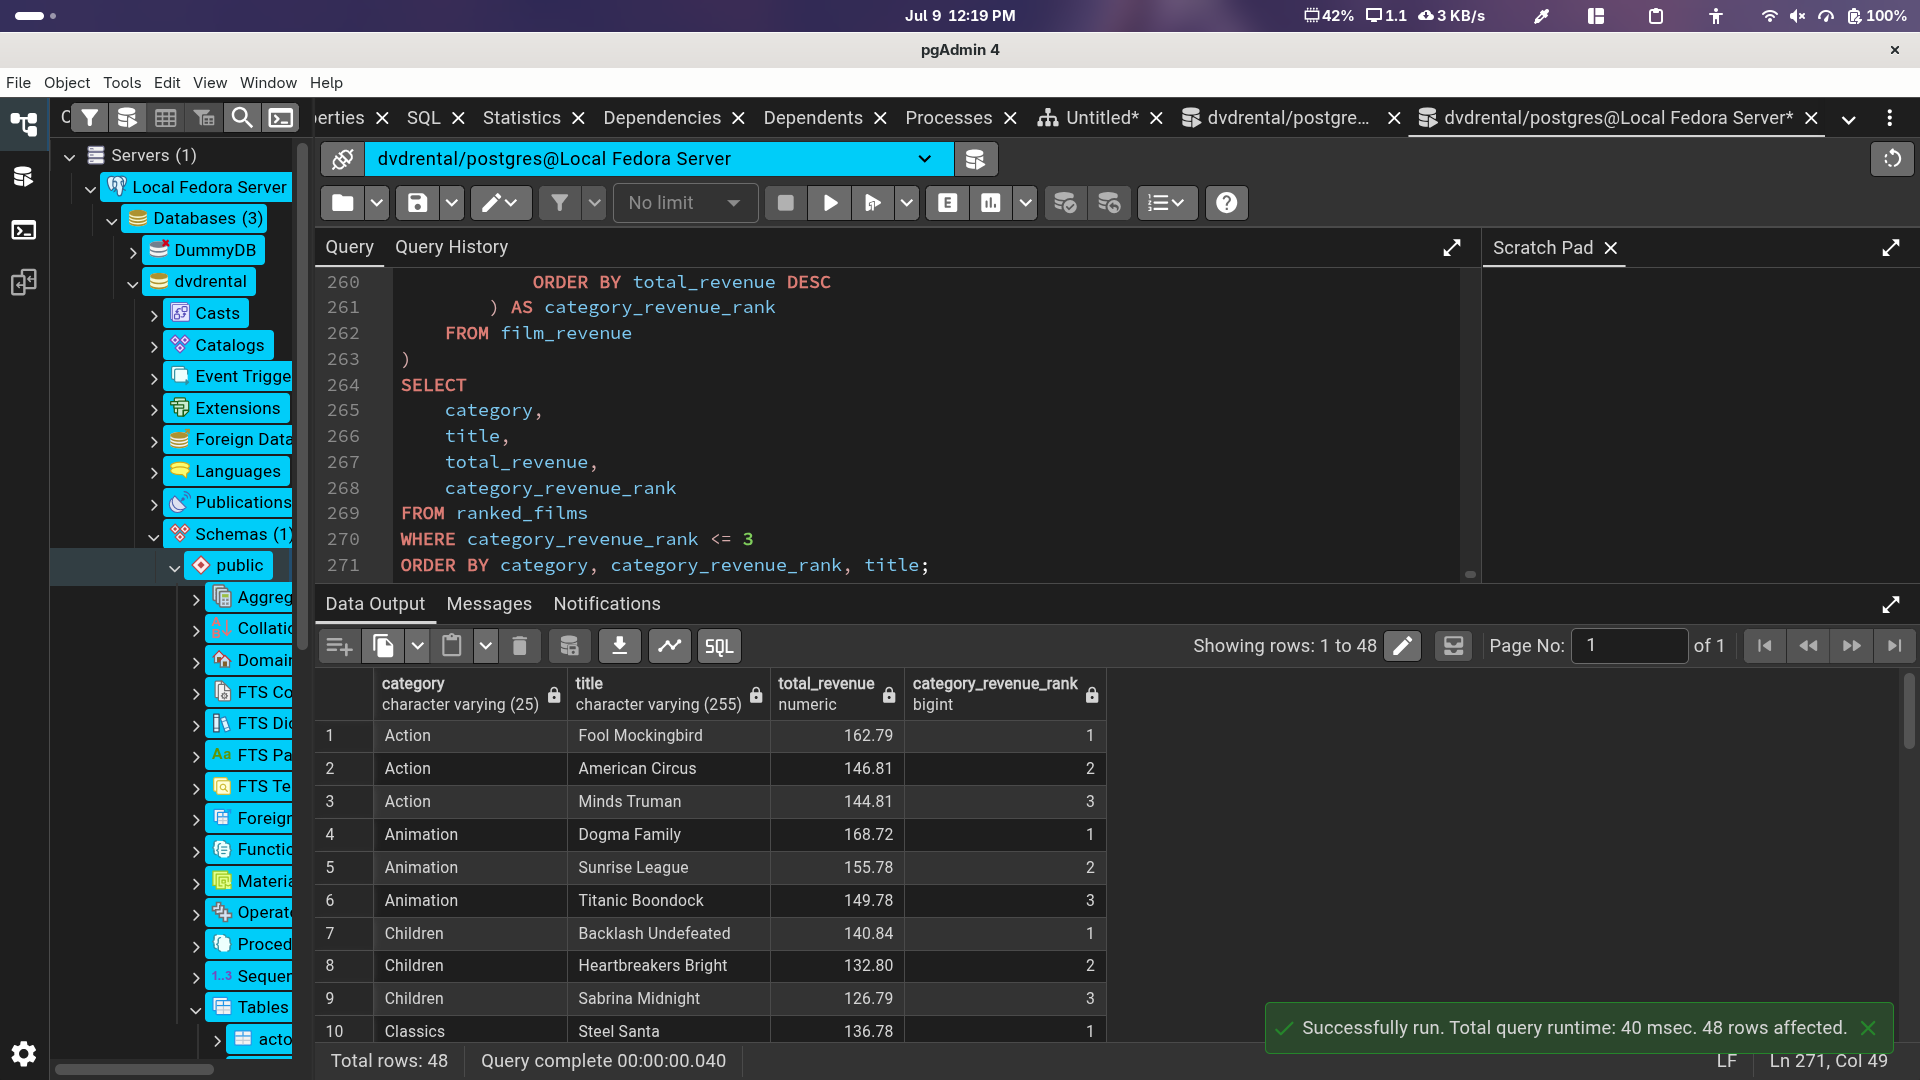

---

#### Bonus Challenge
Without looking at any online solution, write a single query (using CTEs) that finds: Which staff member processed the highest revenue in each store, and what percentage of that store's total revenue did they contribute? This requires combining aggregation, a CTE, and a percentage calculation in the same query.

- ganna be honest, doing complicated CTEs and subqueries without an AI help whatsoever is pretty hard and needs a lot more practice to get good at so I am just going to leave the bonus task untouched. 

---

#### Deliverables
Submit:
##### 1. aggregation_subqueries.sql — All SQL queries, clearly commented by section.
- Please view Week-3/Day-3/SQL-Files/aggregation_subqueries.sql
##### 2. README.md — Include:
- Explanation of when to use a subquery vs a CTE vs a window function.
- Explanation of how each business question was solved.
- Three business insights from the results.
##### 3. Screenshots — Include screenshots of:
- Query Results for Part 2 and Part 3
- Successful execution of all queries


---